# Wikipedia Editing Behavior Analysis
## Exploratory Data Analysis

Version: 11/17/2025

This notebook does exploratory analysis on political events' correlation with Wikipedia editing behavior on Chinese Wikipedia pages related to Taiwan politics, to gain a sense of the overall pattern before doing the implementing prospectus design. 

All data reflects aggregated editing data of selected pages (775 pages related to presidential/legislative elections in 2016, 2020, 2024. The two elections occur on the same day in Taiwan after 2012.)


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import json
from datetime import datetime, timedelta
from pathlib import Path
import matplotlib.font_manager as fm
import warnings

# Suppress font warnings (Chinese characters will still display correctly)
warnings.filterwarnings('ignore', category=UserWarning, message='.*Glyph.*missing from font.*')

# Find and set Chinese font
def get_chinese_font():
    """Find available Chinese fonts on the system"""
    chinese_fonts = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC', 'STHeiti', 
                     'SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei']
    
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in chinese_fonts:
        if font in available_fonts:
            return font
    
    # If no Chinese font found, return default
    return 'DejaVu Sans'

# Set seaborn style FIRST
sns.set_style('whitegrid')
%matplotlib inline

# THEN set Chinese font (after seaborn to prevent override)
chinese_font = get_chinese_font()
plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False  # Fix minus sign display
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Using font: {chinese_font}")

Using font: Arial Unicode MS


## Load Data

Load the processed datasets and political events timeline.


In [39]:
# Load processed datasets
data_dir = Path('../data/processed')

df_daily = pd.read_csv(data_dir / 'daily_edits.csv', parse_dates=['date'])
df_pages = pd.read_csv(data_dir / 'page_statistics.csv')

# Load political events
with open('../data/events/political_events.json', 'r', encoding='utf-8') as f:
    events_data = json.load(f)
    events = pd.DataFrame(events_data['events'])
    events['date'] = pd.to_datetime(events['date'])

print(f"Loaded daily data for {df_pages.shape[0]} pages")
print(f"Tracking {len(events)} political events")


Loaded daily data for 215 pages
Tracking 5 political events


## 1. Overview Statistics


In [40]:
# Basic statistics
print("Dataset Overview")
print("=" * 60)
print(f"Pages: {len(df_pages)}")
print(f"Date range: {df_daily['date'].min()} to {df_daily['date'].max()}")
print(f"Total days: {len(df_daily['date'].unique())}")
print(f"Total edits: {df_daily['num_edits'].sum():,}")
print(f"\nTop 5 Most Edited Pages:")
print(df_pages.nlargest(5, 'total_edits')[['page_title', 'total_edits', 'unique_editors']])


Dataset Overview
Pages: 215
Date range: 2015-01-01 00:00:00 to 2024-12-31 00:00:00
Total days: 3635
Total edits: 111,105

Top 5 Most Edited Pages:
              page_title  total_edits  unique_editors
85                 中國國民黨         4708            1615
38   2018年中華民國直轄市長及縣市長選舉         4416             933
66   2022年中華民國直轄市長及縣市長選舉         4231             691
49       2020年中華民國立法委員選舉         3885             747
189                  蔡英文         3858            1003


## 2. Time Series: Daily Editing Activity

**Methodological Note**: All moving averages in this analysis use **backward-looking windows**. The 7-day moving average at day *t* represents the average of days (*t*-6, *t*-5, ..., *t*-1, *t*). This is crucial for pre-election analysis because it ensures that averages for days before an election do not include post-election data, preventing contamination of the pre-election signal.


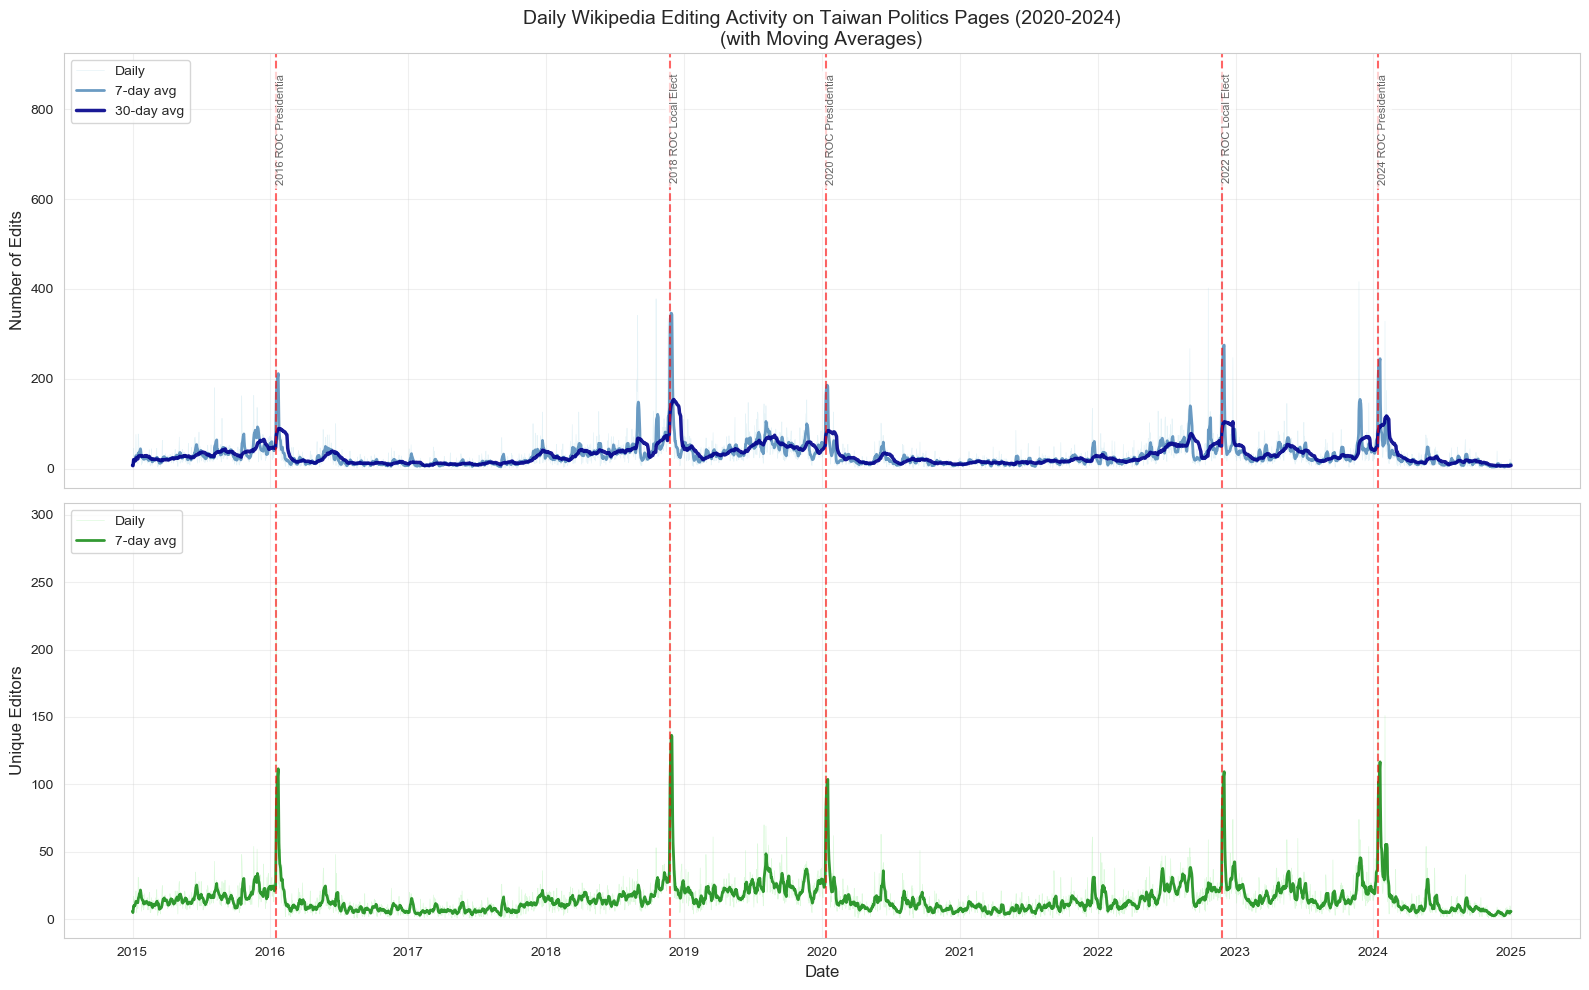


Peak editing day: 2022-11-26
Peak edits: 881 edits
Average daily edits: 30.6


In [41]:
# Aggregate daily activity across all pages
daily_aggregate = df_daily.groupby('date').agg({
    'num_edits': 'sum',
    'unique_editors': 'sum'
}).reset_index()

# Calculate moving averages (7-day and 30-day)
# Using BACKWARD-LOOKING windows: MA at day t = average of days (t-6, t-5, ..., t-1, t)
# This ensures pre-election averages don't include post-election data
daily_aggregate['ma7_edits'] = daily_aggregate['num_edits'].rolling(window=7, min_periods=1).mean()
daily_aggregate['ma30_edits'] = daily_aggregate['num_edits'].rolling(window=30, min_periods=1).mean()
daily_aggregate['ma7_editors'] = daily_aggregate['unique_editors'].rolling(window=7, min_periods=1).mean()

# Create time series plot with moving averages
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot 1: Edit volume
# Daily data (light, in background)
axes[0].plot(daily_aggregate['date'], daily_aggregate['num_edits'], 
            linewidth=0.5, alpha=0.3, color='lightblue', label='Daily')
# 7-day moving average (main line)
axes[0].plot(daily_aggregate['date'], daily_aggregate['ma7_edits'], 
            linewidth=2, alpha=0.8, color='steelblue', label='7-day avg')
# 30-day moving average (trend)
axes[0].plot(daily_aggregate['date'], daily_aggregate['ma30_edits'], 
            linewidth=2.5, alpha=0.9, color='darkblue', label='30-day avg')

axes[0].set_ylabel('Number of Edits', fontsize=12)
axes[0].set_title('Daily Wikipedia Editing Activity on Taiwan Politics Pages (2020-2024)\n(with Moving Averages)', 
                 fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', fontsize=10)

# Mark political events
for _, event in events.iterrows():
    axes[0].axvline(event['date'], color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    # Add event labels (rotated)
    y_pos = axes[0].get_ylim()[1] * 0.95
    axes[0].text(event['date'], y_pos, 
                event['name'][:20], rotation=90, 
                verticalalignment='top', fontsize=8, alpha=0.7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Plot 2: Unique editors
axes[1].plot(daily_aggregate['date'], daily_aggregate['unique_editors'], 
            linewidth=0.5, alpha=0.3, color='lightgreen', label='Daily')
axes[1].plot(daily_aggregate['date'], daily_aggregate['ma7_editors'], 
            linewidth=2, alpha=0.8, color='green', label='7-day avg')
axes[1].set_ylabel('Unique Editors', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left', fontsize=10)

# Mark political events
for _, event in events.iterrows():
    axes[1].axvline(event['date'], color='red', linestyle='--', alpha=0.6, linewidth=1.5)

plt.tight_layout()
plt.show()

print(f"\nPeak editing day: {daily_aggregate.loc[daily_aggregate['num_edits'].idxmax(), 'date'].date()}")
print(f"Peak edits: {daily_aggregate['num_edits'].max()} edits")
print(f"Average daily edits: {daily_aggregate['num_edits'].mean():.1f}")


### 2b. Interactive Time Series

Interactive version (requires plotly).


In [42]:
# Interactive plot with Plotly (install with: conda install plotly)
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    # Create figure with subplots
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        subplot_titles=('Edit Volume (with 7-day Moving Average)', 'Unique Editors (with 7-day Moving Average)'),
        vertical_spacing=0.1
    )
    
    # Add edit traces
    fig.add_trace(
        go.Scatter(x=daily_aggregate['date'], y=daily_aggregate['num_edits'],
                  mode='lines', name='Daily Edits', 
                  line=dict(color='lightblue', width=1), opacity=0.3),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=daily_aggregate['date'], y=daily_aggregate['ma7_edits'],
                  mode='lines', name='7-day Avg Edits',
                  line=dict(color='steelblue', width=2)),
        row=1, col=1
    )
    
    # Add editor traces
    fig.add_trace(
        go.Scatter(x=daily_aggregate['date'], y=daily_aggregate['unique_editors'],
                  mode='lines', name='Daily Editors',
                  line=dict(color='lightgreen', width=1), opacity=0.3),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter(x=daily_aggregate['date'], y=daily_aggregate['ma7_editors'],
                  mode='lines', name='7-day Avg Editors',
                  line=dict(color='green', width=2)),
        row=2, col=1
    )
    
    # Add event markers using scatter traces (most reliable method)
    for _, event in events.iterrows():
        # Get y-axis ranges
        max_edits = daily_aggregate['num_edits'].max()
        max_editors = daily_aggregate['unique_editors'].max()
        
        # Add vertical line as scatter trace for edits plot
        fig.add_trace(
            go.Scatter(
                x=[event['date'], event['date']],
                y=[0, max_edits],
                mode='lines',
                line=dict(color='red', width=1.5, dash='dash'),
                showlegend=False,
                hoverinfo='skip'
            ),
            row=1, col=1
        )
        
        # Add vertical line for editors plot
        fig.add_trace(
            go.Scatter(
                x=[event['date'], event['date']],
                y=[0, max_editors],
                mode='lines',
                line=dict(color='red', width=1.5, dash='dash'),
                showlegend=False,
                hoverinfo='skip'
            ),
            row=2, col=1
        )
    
    # Update layout
    fig.update_layout(
        height=800,
        title_text="Interactive: Wikipedia Editing Activity on Taiwan Politics Pages (2020-2024)<br><sub>Red dashed lines mark political events</sub>",
        hovermode='x unified',
        showlegend=True
    )
    
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Number of Edits", row=1, col=1)
    fig.update_yaxes(title_text="Unique Editors", row=2, col=1)
    
    # Show interactive plot
    fig.show()
    
    print("Note: Red dashed lines mark political events")
    
except ImportError:
    print("Plotly not installed. To use interactive plots, run: conda install plotly")
except Exception as e:
    print(f"Error creating interactive plot: {e}")


Note: Red dashed lines mark political events


## 3. Event Analysis: Pre vs Post Comparison


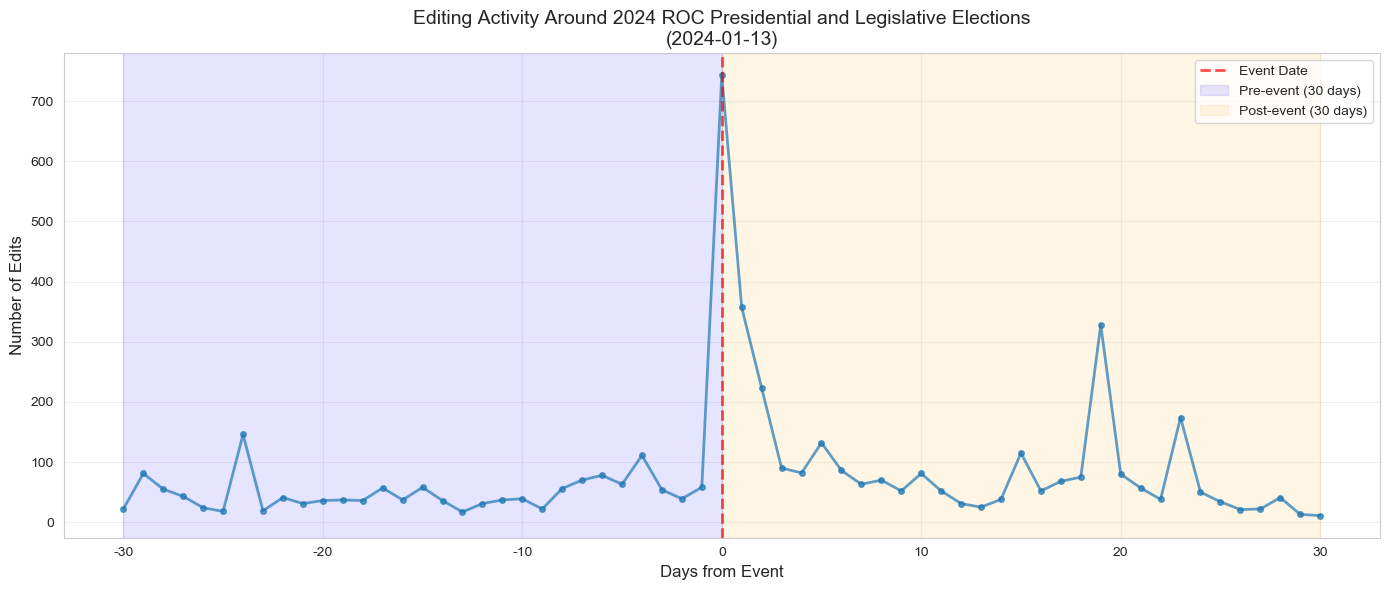


2024 ROC Presidential and Legislative Elections
Pre-event average (30 days): 48.4 edits/day
Post-event average (30 days): 85.4 edits/day
Change: +76.4%


In [43]:
# Analyze editing activity around political events
def analyze_event_impact(event_date, event_name, window_days=30):
    """Analyze editing activity before and after an event"""
    pre_start = event_date - timedelta(days=window_days)
    post_end = event_date + timedelta(days=window_days)
    
    # Filter data
    mask = (daily_aggregate['date'] >= pre_start) & (daily_aggregate['date'] <= post_end)
    event_data = daily_aggregate[mask].copy()
    
    # Label periods
    event_data['period'] = 'pre'
    event_data.loc[event_data['date'] > event_date, 'period'] = 'post'
    event_data.loc[event_data['date'] == event_date, 'period'] = 'event'
    event_data['days_from_event'] = (event_data['date'] - event_date).dt.days
    
    return event_data

# Analyze 2024 election
event_2024 = events[events['event_id'] == 'tw_election_2024'].iloc[0]
event_data_2024 = analyze_event_impact(event_2024['date'], event_2024['name'])

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot editing activity
ax.plot(event_data_2024['days_from_event'], event_data_2024['num_edits'], 
       marker='o', linewidth=2, markersize=4, alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Event Date', alpha=0.7)
ax.axvspan(-30, 0, alpha=0.1, color='blue', label='Pre-event (30 days)')
ax.axvspan(0, 30, alpha=0.1, color='orange', label='Post-event (30 days)')

ax.set_xlabel('Days from Event', fontsize=12)
ax.set_ylabel('Number of Edits', fontsize=12)
ax.set_title(f'Editing Activity Around {event_2024["name"]}\n({event_2024["date"].date()})', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate statistics
pre_avg = event_data_2024[event_data_2024['period'] == 'pre']['num_edits'].mean()
post_avg = event_data_2024[event_data_2024['period'] == 'post']['num_edits'].mean()
change_pct = ((post_avg - pre_avg) / pre_avg) * 100

print(f"\n{event_2024['name']}")
print("=" * 60)
print(f"Pre-event average (30 days): {pre_avg:.1f} edits/day")
print(f"Post-event average (30 days): {post_avg:.1f} edits/day")
print(f"Change: {change_pct:+.1f}%")


## 4. Page-Level Analysis


In [44]:
# Interactive Page-Level Analysis with Plotly
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import numpy as np
    
    # Get top 20 pages
    top_20 = df_pages.nlargest(20, 'total_edits')
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=(
            'Top 20 Most Edited Pages',
            'Distribution of Edit Volume',
            'Concentration of Editing Activity'
        ),
        column_widths=[0.35, 0.3, 0.35],
        horizontal_spacing=0.15
    )
    
    # 1. Top 20 pages (horizontal bar)
    fig.add_trace(
        go.Bar(
            y=top_20['page_title'][::-1],  # Reverse to show highest at top
            x=top_20['total_edits'][::-1],
            orientation='h',
            marker=dict(color='steelblue'),
            hovertemplate='<b>%{y}</b><br>Edits: %{x:,}<br>Editors: %{customdata:,}<extra></extra>',
            customdata=top_20['unique_editors'][::-1]
        ),
        row=1, col=1
    )
    
    # 2. Distribution histogram
    fig.add_trace(
        go.Histogram(
            x=df_pages['total_edits'],
            nbinsx=50,
            marker=dict(color='steelblue', line=dict(color='black', width=1)),
            hovertemplate='Edits: %{x}<br>Pages: %{y}<extra></extra>'
        ),
        row=1, col=2
    )
    
    # Add median line to histogram (without annotation via add_vline)
    median_edits = df_pages['total_edits'].median()
    fig.add_vline(
        x=median_edits,
        line_dash="dash",
        line_color="red",
        row=1, col=2
    )
    
    # Add median annotation inside the histogram (second subplot)
    fig.add_annotation(
        x=median_edits,
        y=0.95,
        xref='x2',
        yref='y2 domain',
        text=f"Median: {median_edits:.0f}",
        showarrow=False,
        font=dict(size=10, color="red"),
        bgcolor="white",
        opacity=0.8
    )
    
    # 3. Cumulative concentration curve (Lorenz-like)
    sorted_edits = df_pages.sort_values('total_edits', ascending=False)
    cumulative_pct = (sorted_edits['total_edits'].cumsum() / sorted_edits['total_edits'].sum() * 100)
    page_pct = np.arange(1, len(sorted_edits) + 1) / len(sorted_edits) * 100
    
    # Concentration curve
    fig.add_trace(
        go.Scatter(
            x=page_pct,
            y=cumulative_pct,
            mode='lines',
            line=dict(color='steelblue', width=2),
            name='Actual',
            hovertemplate='%{x:.1f}% of pages<br>%{y:.1f}% of edits<extra></extra>'
        ),
        row=1, col=3
    )
    
    # Perfect equality line
    fig.add_trace(
        go.Scatter(
            x=[0, 100],
            y=[0, 100],
            mode='lines',
            line=dict(color='red', width=2, dash='dash'),
            name='Perfect equality',
            hovertemplate='Perfect equality<extra></extra>'
        ),
        row=1, col=3
    )
    
    # Update layout
    fig.update_xaxes(title_text="Total Edits", row=1, col=1)
    fig.update_xaxes(title_text="Total Edits", row=1, col=2)
    fig.update_xaxes(title_text="Cumulative % of Pages", row=1, col=3)
    
    fig.update_yaxes(title_text="", row=1, col=1)
    fig.update_yaxes(title_text="Number of Pages", row=1, col=2)
    fig.update_yaxes(title_text="Cumulative % of Edits", row=1, col=3)
    
    fig.update_layout(
        height=600,
        width=1400,
        showlegend=True,
        title_text="Page-Level Editing Activity Analysis (Interactive)",
        title_x=0.5,
        hovermode='closest'
    )
    
    # Adjust subplot title positioning to prevent overlap
    for annotation in fig['layout']['annotations']:
        annotation['y'] = 1.05  # Move titles higher
    
    fig.show()
    
    # Print concentration statistics
    print("\n" + "="*60)
    print("EDITING CONCENTRATION STATISTICS")
    print("="*60)
    
    total_edits = sorted_edits['total_edits'].sum()
    print(f"Total pages: {len(df_pages):,}")
    print(f"Total edits: {total_edits:,}")
    print(f"\nConcentration:")
    print(f"  Top 5 pages:  {(sorted_edits.head(5)['total_edits'].sum() / total_edits * 100):>6.1f}% of all edits")
    print(f"  Top 10 pages: {(sorted_edits.head(10)['total_edits'].sum() / total_edits * 100):>6.1f}% of all edits")
    print(f"  Top 20 pages: {(sorted_edits.head(20)['total_edits'].sum() / total_edits * 100):>6.1f}% of all edits")
    print(f"  Top 50 pages: {(sorted_edits.head(50)['total_edits'].sum() / total_edits * 100):>6.1f}% of all edits")
    
    print(f"\nDistribution:")
    print(f"  Median edits per page: {df_pages['total_edits'].median():,.0f}")
    print(f"  Mean edits per page:   {df_pages['total_edits'].mean():,.0f}")
    print(f"  Std deviation:         {df_pages['total_edits'].std():,.0f}")
    
    print(f"\nTop 5 Most Edited Pages:")
    for i, row in sorted_edits.head(5).iterrows():
        print(f"  {row['page_title'][:50]:50s} {row['total_edits']:>6,} edits ({row['unique_editors']:>4,} editors)")
    
except ImportError:
    print("Plotly not installed. Install with: conda install plotly")
    
    # Fallback: Static matplotlib version (Top 20 only)
    top_20 = df_pages.nlargest(20, 'total_edits')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(range(len(top_20)), top_20['total_edits'][::-1])
    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels(top_20['page_title'][::-1], fontsize=10)
    ax.set_xlabel('Total Edits', fontsize=11)
    ax.set_title('Top 20 Most Edited Pages', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()



EDITING CONCENTRATION STATISTICS
Total pages: 215
Total edits: 111,105

Concentration:
  Top 5 pages:    19.0% of all edits
  Top 10 pages:   35.1% of all edits
  Top 20 pages:   55.9% of all edits
  Top 50 pages:   83.0% of all edits

Distribution:
  Median edits per page: 128
  Mean edits per page:   517
  Std deviation:         941

Top 5 Most Edited Pages:
  中國國民黨                                               4,708 edits (1,615 editors)
  2018年中華民國直轄市長及縣市長選舉                                 4,416 edits ( 933 editors)
  2022年中華民國直轄市長及縣市長選舉                                 4,231 edits ( 691 editors)
  2020年中華民國立法委員選舉                                     3,885 edits ( 747 editors)
  蔡英文                                                 3,858 edits (1,003 editors)


## 5. Weekly patterns, Monthly trends


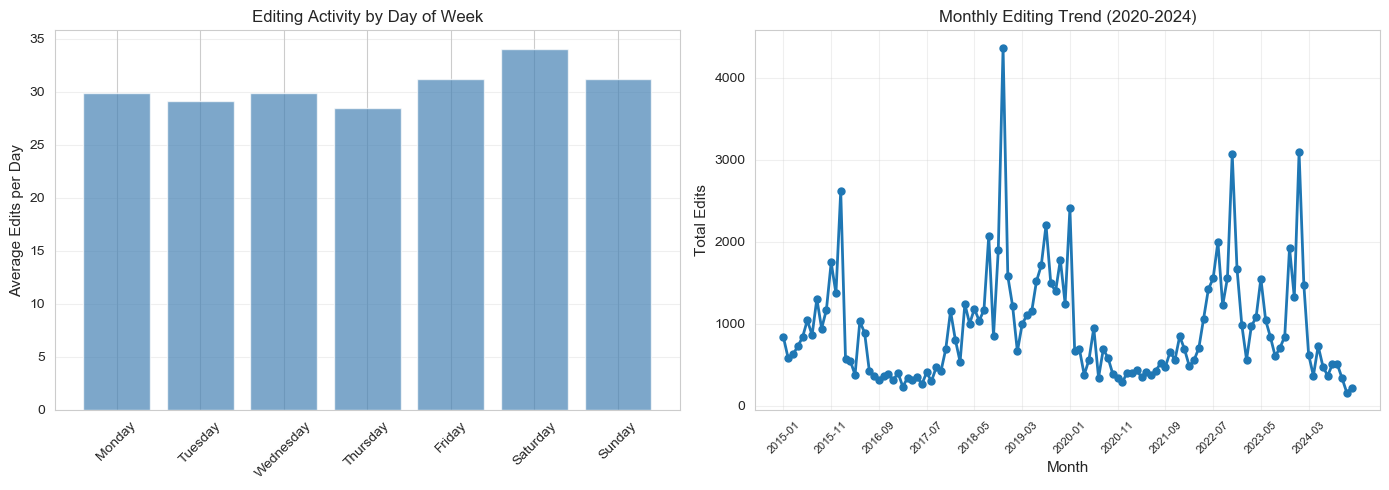

In [45]:
# Day of week patterns
daily_aggregate['dayofweek'] = daily_aggregate['date'].dt.dayofweek
daily_aggregate['month'] = daily_aggregate['date'].dt.to_period('M')

# Aggregate by day of week
dow_stats = daily_aggregate.groupby('dayofweek').agg({
    'num_edits': 'mean',
    'unique_editors': 'mean'
}).reset_index()

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week pattern
axes[0].bar(dow_stats['dayofweek'], dow_stats['num_edits'], color='steelblue', alpha=0.7)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names, rotation=45)
axes[0].set_ylabel('Average Edits per Day', fontsize=11)
axes[0].set_title('Editing Activity by Day of Week', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Monthly trend
monthly_stats = daily_aggregate.groupby('month').agg({
    'num_edits': 'sum'
}).reset_index()
monthly_stats['month_str'] = monthly_stats['month'].astype(str)

axes[1].plot(range(len(monthly_stats)), monthly_stats['num_edits'], marker='o', linewidth=2, markersize=5)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Total Edits', fontsize=11)
axes[1].set_title('Monthly Editing Trend (2020-2024)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
# Show every 6th month label
step = max(1, len(monthly_stats) // 12)
axes[1].set_xticks(range(0, len(monthly_stats), step))
axes[1].set_xticklabels(monthly_stats['month_str'].iloc[::step], rotation=45, fontsize=8)

plt.tight_layout()
plt.show()


## 6. Pre-Election Dynamics: Event Study Analysis

We now focus on pre-election periods because
1. Post-election editing may primarily reflect mechanical updates of election results
2. Pre-election information has the potential to influence public opinion and voter behavior
3. Pre-election editing patterns may reveal anticipatory information-seeking and deliberative processes

**Analysis Strategy:**
- Compare editing activity in different pre-election windows (90 days, 30 days) against baseline
- Separate analysis for 3 national elections and 2 local elections
- Break down by page type: legislators, parties, and general political pages


In [46]:
# Enhanced 7-Category Classification System
def categorize_page_detailed(title):
    """
    Categorize pages into 7 detailed categories
    
    Categories:
        1. politician - Individual politicians (legislators, candidates, mayors)
        2. party - Political party pages (organization, structure)
        3. election_event - Election overview pages
        4. campaign_dynamic - Campaign events, primaries, polls, debates
        5. referendum - Referendum/public vote pages
        6. movement - Political movements (太陽花, 反送中, etc.)
        7. policy_issue - Policy debate pages (同性婚姻, 核能, etc.)
    """
    
    # Campaign slogans & events (Category 4)
    campaign_keywords = ['換柱', '點亮', '周子瑜', '唯一支持', '放韓', '信賴', '君悅', '國政顧問']
    if any(kw in title for kw in campaign_keywords):
        return 'campaign_dynamic'
    
    # Primary elections & polls & debates (Category 4)
    if '提名' in title or '初選' in title or '民意調查' in title or '電視辯論' in title:
        return 'campaign_dynamic'
    
    # Referendums (Category 5)
    if '公投' in title or '公民投票' in title:
        return 'referendum'
    
    # Political movements (Category 6)
    if any(kw in title for kw in ['太陽花', '學運', '反送中', '抗議', '運動']):
        return 'movement'
    
    # Policy issues (Category 7)
    if any(kw in title for kw in ['同性婚姻', '核能', '能源政策', '兩岸關係', '獨立運動', '貿易壁壘']):
        return 'policy_issue'
    
    # Party pages (Category 2) - must come after "提名" check
    party_keywords = ['民進黨', '國民黨', '時代力量', '台灣民眾黨', '親民黨', '新黨', 
                      '台灣團結聯盟', '綠黨']
    # Check for party organizational pages (not individual members)
    if any(kw + '黨' in title for kw in ['民進', '國民', '民眾', '親民']) and '黨員' not in title:
        if any(org in title for org in ['委員會', '代表大會', '主席', '黨團', '歷任', '參政']):
            return 'party'
    if '黨' in title and any(org in title for org in ['主席', '秘書長', '組織']):
        return 'party'
    
    # Election overview pages (Category 3)
    if '選舉' in title and any(y in title for y in ['2016', '2018', '2020', '2022', '2024']):
        # Exclude individual candidate pages
        if not any(name in title for name in ['參與', '角逐']) or '選舉區' in title:
            if any(kw in title for kw in ['總統選舉', '立法委員選舉', '縣市長選舉', '地方選舉', '九合一']):
                return 'election_event'
    
    # Default: individual politician (Category 1)
    return 'politician'


def aggregate_categories(detailed_category):
    """
    Create aggregated 3-category system:
    - politician: Individual politicians
    - party: Party pages
    - general_context: Everything else (election events, campaigns, referendums, movements, policy issues)
    """
    if detailed_category == 'politician':
        return 'politician'
    elif detailed_category == 'party':
        return 'party'
    else:
        # Aggregate categories 3-7
        return 'general_context'


# Load all pages and create category mappings
with open('../data/raw/page_list.json', 'r', encoding='utf-8') as f:
    page_data = json.load(f)

# Create dictionaries for both detailed and aggregated categories
page_categories_detailed = {}
page_categories_aggregated = {}

for page in page_data['pages']:
    title = page['title']
    detailed_cat = categorize_page_detailed(title)
    
    page_categories_detailed[title] = detailed_cat
    page_categories_aggregated[title] = aggregate_categories(detailed_cat)

# Show distributions
print("="*70)
print("DETAILED 7-CATEGORY DISTRIBUTION")
print("="*70)
detailed_counts = pd.Series(page_categories_detailed).value_counts()
for cat, count in detailed_counts.items():
    print(f"  {cat:20s}: {count:4d} pages")

print(f"\nTotal pages classified: {len(page_categories_detailed)}")

print("\n" + "="*70)
print("AGGREGATED 3-CATEGORY DISTRIBUTION")
print("="*70)
aggregated_counts = pd.Series(page_categories_aggregated).value_counts()
for cat, count in aggregated_counts.items():
    print(f"  {cat:20s}: {count:4d} pages")

print("\n" + "="*70)
print("Note: Use 'page_categories_detailed' for fine-grained analysis")
print("      Use 'page_categories_aggregated' for simpler 3-category analysis")
print("="*70)

# For backward compatibility, set default to aggregated
page_categories = page_categories_aggregated


DETAILED 7-CATEGORY DISTRIBUTION
  politician          :  166 pages
  campaign_dynamic    :   20 pages
  election_event      :   14 pages
  referendum          :   10 pages
  party               :    8 pages
  movement            :    3 pages
  policy_issue        :    1 pages

Total pages classified: 222

AGGREGATED 3-CATEGORY DISTRIBUTION
  politician          :  166 pages
  general_context     :   48 pages
  party               :    8 pages

Note: Use 'page_categories_detailed' for fine-grained analysis
      Use 'page_categories_aggregated' for simpler 3-category analysis


### Category System Explanation

**Two Classification Systems Available**:

**1. Aggregated 3-Category System** (for main analysis):
- **politician**: Individual politicians, legislators, candidates, mayors
- **party**: Political party organizational pages
- **general_context**: All other electoral context (aggregates categories 3-7 below)

**2. Detailed 7-Category System** (for fine-grained analysis):
1. **politician**: Individual political figures
2. **party**: Party structures and organizations
3. **election_event**: Election overview pages (總統選舉, 立委選舉, etc.)
4. **campaign_dynamic**: Campaign events, primaries, polls, debates (換柱爭議, 民意調查, etc.)
5. **referendum**: Referendum and public vote pages (公投)
6. **movement**: Political movements (太陽花學運, 反送中, etc.)
7. **policy_issue**: Policy debates (同性婚姻, 核能, 兩岸關係, etc.)

**Why Two Systems?**
- **Aggregated**: Cleaner for main hypothesis testing, better statistical power
- **Detailed**: Reveals nuanced patterns (e.g., do referendums peak differently than elections?)


In [47]:
# Load all election evnets
with open('../data/events/political_events.json', 'r', encoding='utf-8') as f:
    events_data = json.load(f)

events_all = pd.DataFrame(events_data['events'])
events_all['date'] = pd.to_datetime(events_all['date'])

# Separate national and local
events_national = events_all[events_all['type'] == 'national'].sort_values('date')
events_local = events_all[events_all['type'] == 'local'].sort_values('date')

print("National Elections (3):")
for _, event in events_national.iterrows():
    print(f"  {event['date'].strftime('%Y-%m-%d')}: {event['name']}")

print("\nLocal Elections (2):")
for _, event in events_local.iterrows():
    print(f"  {event['date'].strftime('%Y-%m-%d')}: {event['name']}")

print(f"\nTotal: {len(events_all)} elections for analysis")


National Elections (3):
  2016-01-16: 2016 ROC Presidential and Legislative Elections
  2020-01-11: 2020 ROC Presidential and Legislative Elections
  2024-01-13: 2024 ROC Presidential and Legislative Elections

Local Elections (2):
  2018-11-24: 2018 ROC Local Elections (九合一選舉)
  2022-11-26: 2022 ROC Local Elections (九合一選舉)

Total: 5 elections for analysis


### 6a. Event Study: Aggregate Editing Activity Around Each Election

**Note**: All 7-day moving averages use backward-looking windows, meaning the average at day t reflects days (t-6) through t. This ensures that pre-election averages contain only pre-election data and are not contaminated by post-election editing.


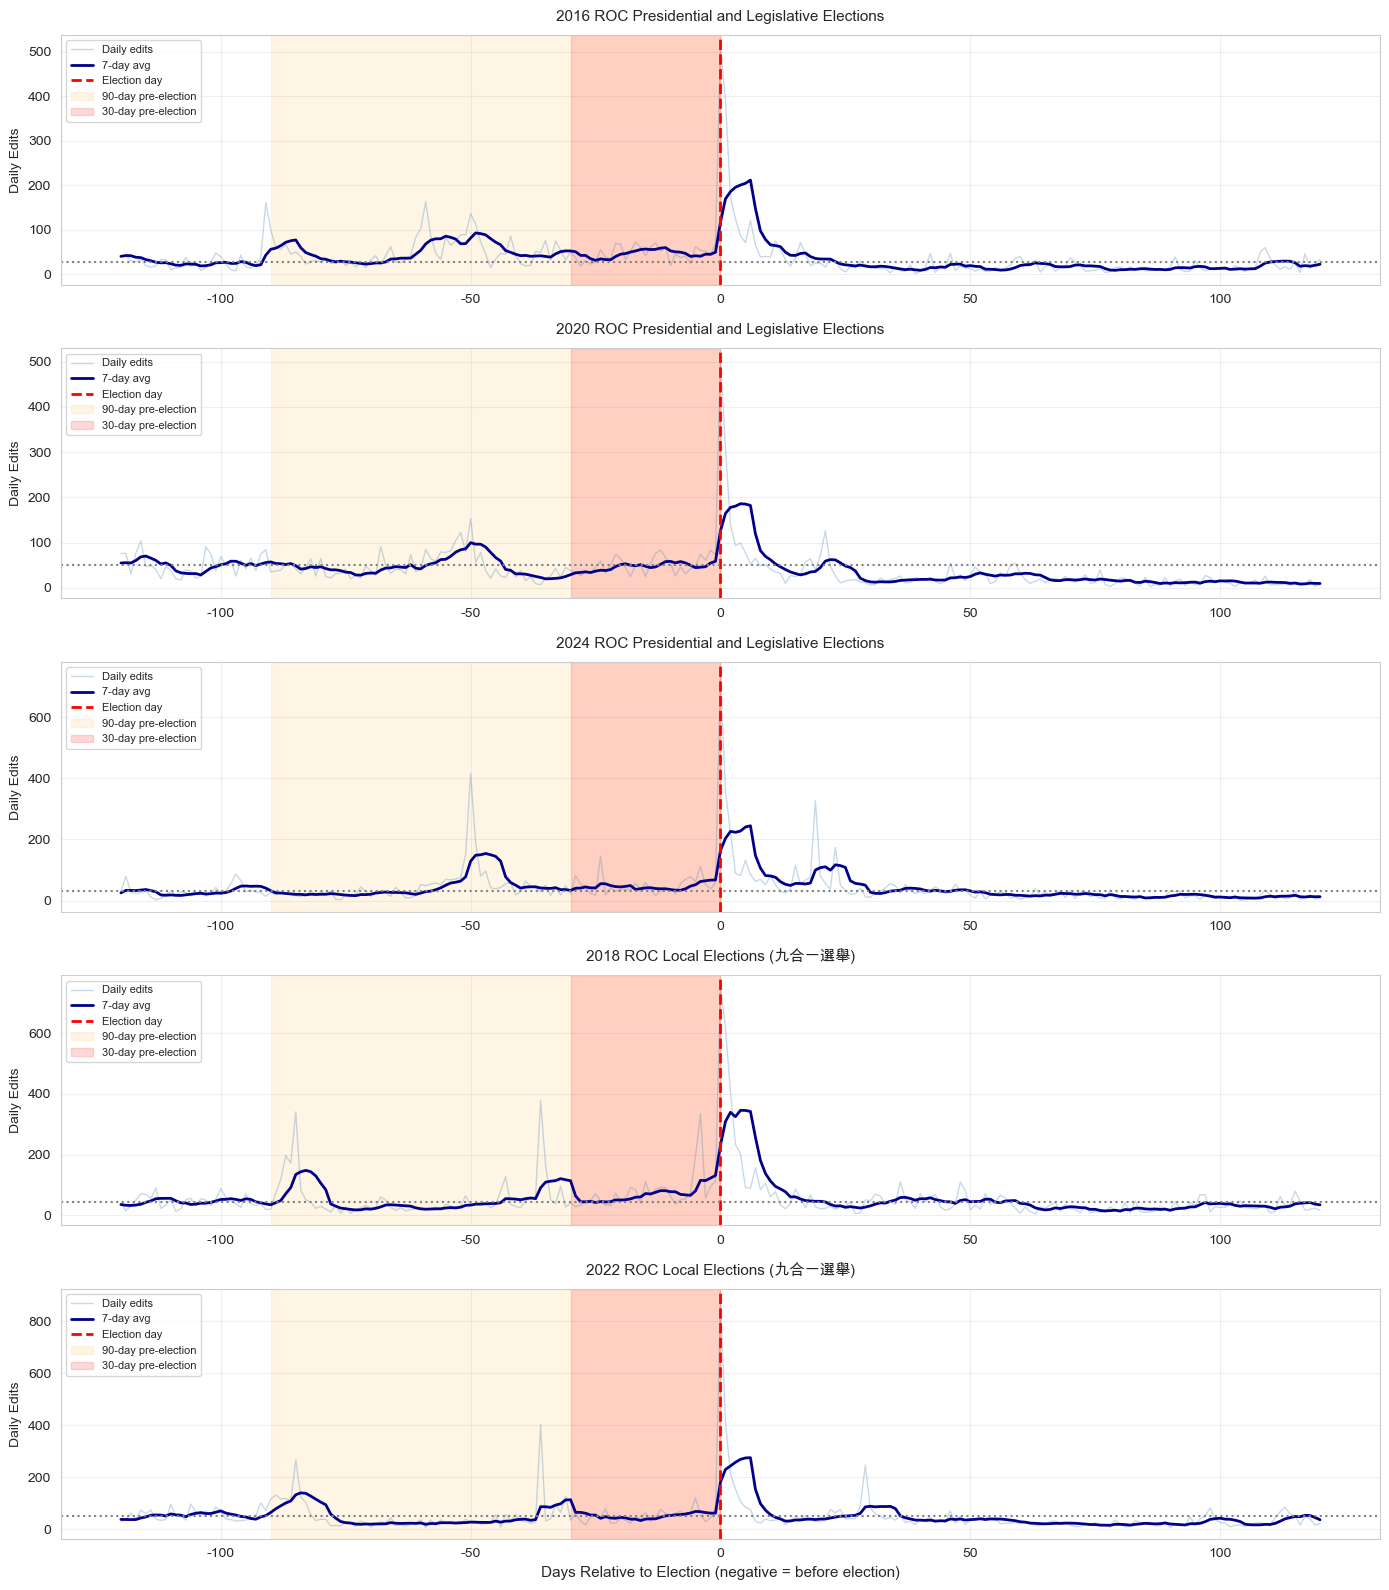

Shaded regions highlight pre-election windows of interest


In [48]:
# Event study visualization: 5 panels (3 national + 2 local)
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=False)

# Create event study plot
def plot_event_study(ax, event_date, event_name, window_days=120):
    """Plot editing activity around a specific election"""
    start_date = event_date - pd.Timedelta(days=window_days)
    end_date = event_date + pd.Timedelta(days=window_days)
    
    # Filter data
    mask = (daily_aggregate['date'] >= start_date) & (daily_aggregate['date'] <= end_date)
    event_data = daily_aggregate[mask].copy()
    
    if len(event_data) == 0:
        ax.text(0.5, 0.5, f'No data available for {event_name}', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(event_name, fontsize=11, fontweight='bold')
        return
    
    # Calculate days relative to election
    event_data['days_to_election'] = (event_data['date'] - event_date).dt.days
    
    # Plot with 7-day moving average
    ax.plot(event_data['days_to_election'], event_data['num_edits'], 
            alpha=0.3, color='steelblue', linewidth=1, label='Daily edits')
    ax.plot(event_data['days_to_election'], event_data['ma7_edits'], 
            color='darkblue', linewidth=2, label='7-day avg')
    
    # Mark election day
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Election day')
    
    # Shade pre-election windows
    ax.axvspan(-90, 0, alpha=0.1, color='orange', label='90-day pre-election')
    ax.axvspan(-30, 0, alpha=0.15, color='red', label='30-day pre-election')
    
    # Formatting
    ax.set_ylabel('Daily Edits', fontsize=10)
    ax.set_title(event_name, fontsize=11, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')
    
    # Add baseline reference (average of days -120 to -91)
    baseline_mask = (event_data['days_to_election'] >= -120) & (event_data['days_to_election'] <= -90)
    if baseline_mask.sum() > 0:
        baseline_mean = event_data[baseline_mask]['ma7_edits'].mean()
        ax.axhline(y=baseline_mean, color='gray', linestyle=':', linewidth=1.5, 
                   label=f'Baseline (days -120 to -90): {baseline_mean:.0f}')

# plot each election
idx = 0
for _, event in events_national.iterrows():
    plot_event_study(axes[idx], event['date'], event['name'])
    idx += 1

for _, event in events_local.iterrows():
    plot_event_study(axes[idx], event['date'], event['name'])
    idx += 1

axes[-1].set_xlabel('Days Relative to Election (negative = before election)', fontsize=11)
plt.tight_layout()
plt.show()

print("Shaded regions highlight pre-election windows of interest")


### 6b. Statistical Tests: Pre-Election Increases

Compare editing activity in pre-election windows (30 days, 90 days) against baseline period (days -120 to -91).
Using 90% confidence intervals and t-tests.


In [49]:
from scipy import stats

# Statistical comparison function
def compute_pre_election_stats(event_date, event_name):
    """Compare pre-election periods to baseline"""
    # Define windows
    baseline_start = event_date - pd.Timedelta(days=120)
    baseline_end = event_date - pd.Timedelta(days=91)
    
    pre90_start = event_date - pd.Timedelta(days=90)
    pre90_end = event_date
    
    pre30_start = event_date - pd.Timedelta(days=30)
    pre30_end = event_date
    
    # Extract data
    baseline_data = daily_aggregate[
        (daily_aggregate['date'] >= baseline_start) & 
        (daily_aggregate['date'] < baseline_end)
    ]['num_edits'].values
    
    pre90_data = daily_aggregate[
        (daily_aggregate['date'] >= pre90_start) & 
        (daily_aggregate['date'] < pre90_end)
    ]['num_edits'].values
    
    pre30_data = daily_aggregate[
        (daily_aggregate['date'] >= pre30_start) & 
        (daily_aggregate['date'] < pre30_end)
    ]['num_edits'].values
    
    if len(baseline_data) == 0 or len(pre90_data) == 0 or len(pre30_data) == 0:
        return None
    
    # Compute statistics
    results = {
        'event': event_name,
        'event_date': event_date.strftime('%Y-%m-%d'),
        # Baseline
        'baseline_mean': baseline_data.mean(),
        'baseline_std': baseline_data.std(),
        'baseline_ci90': stats.t.interval(0.90, len(baseline_data)-1, 
                                          loc=baseline_data.mean(), 
                                          scale=stats.sem(baseline_data)),
        # 90-day pre-election
        'pre90_mean': pre90_data.mean(),
        'pre90_std': pre90_data.std(),
        'pre90_ci90': stats.t.interval(0.90, len(pre90_data)-1, 
                                       loc=pre90_data.mean(), 
                                       scale=stats.sem(pre90_data)),
        'pre90_increase_pct': (pre90_data.mean() - baseline_data.mean()) / baseline_data.mean() * 100,
        'pre90_ttest': stats.ttest_ind(pre90_data, baseline_data),
        # 30-day pre-election
        'pre30_mean': pre30_data.mean(),
        'pre30_std': pre30_data.std(),
        'pre30_ci90': stats.t.interval(0.90, len(pre30_data)-1, 
                                       loc=pre30_data.mean(), 
                                       scale=stats.sem(pre30_data)),
        'pre30_increase_pct': (pre30_data.mean() - baseline_data.mean()) / baseline_data.mean() * 100,
        'pre30_ttest': stats.ttest_ind(pre30_data, baseline_data),
    }
    
    return results

# Analyze all elections
results_list = []
for _, event in events_all.iterrows():
    result = compute_pre_election_stats(event['date'], event['name'])
    if result:
        results_list.append(result)

# Results table
print("="*110)
print("PRE-ELECTION EDITING ACTIVITY: STATISTICAL COMPARISON TO BASELINE")
print("="*110)
print(f"{'Election':<50} {'Period':<12} {'Mean':>8} {'90% CI':>20} {'vs Base':>10} {'p-value':>8}")
print("-"*110)

for res in results_list:
    # Baseline
    print(f"{res['event']:<50} {'Baseline':<12} {res['baseline_mean']:>8.1f} "
          f"[{res['baseline_ci90'][0]:>6.1f}, {res['baseline_ci90'][1]:>6.1f}] {'-':>10} {'-':>8}")
    
    # 90-day pre-election
    sig_90 = '***' if res['pre90_ttest'].pvalue < 0.01 else ('**' if res['pre90_ttest'].pvalue < 0.05 else ('*' if res['pre90_ttest'].pvalue < 0.10 else ''))
    print(f"{'':.<50} {'90-day pre':<12} {res['pre90_mean']:>8.1f} "
          f"[{res['pre90_ci90'][0]:>6.1f}, {res['pre90_ci90'][1]:>6.1f}] "
          f"{res['pre90_increase_pct']:>+9.1f}% {res['pre90_ttest'].pvalue:>7.4f}{sig_90}")
    
    # 30-day pre-election
    sig_30 = '***' if res['pre30_ttest'].pvalue < 0.01 else ('**' if res['pre30_ttest'].pvalue < 0.05 else ('*' if res['pre30_ttest'].pvalue < 0.10 else ''))
    print(f"{'':.<50} {'30-day pre':<12} {res['pre30_mean']:>8.1f} "
          f"[{res['pre30_ci90'][0]:>6.1f}, {res['pre30_ci90'][1]:>6.1f}] "
          f"{res['pre30_increase_pct']:>+9.1f}% {res['pre30_ttest'].pvalue:>7.4f}{sig_30}")
    
    print()

print("-"*110)
print("Baseline: days -120 to -91 before election")
print("90-day pre: days -90 to election day")
print("30-day pre: days -30 to election day")
print("Significance: *** p<0.01, ** p<0.05, * p<0.10")
print("="*110)


PRE-ELECTION EDITING ACTIVITY: STATISTICAL COMPARISON TO BASELINE
Election                                           Period           Mean               90% CI    vs Base  p-value
--------------------------------------------------------------------------------------------------------------
2016 ROC Presidential and Legislative Elections    Baseline         25.2 [  21.4,   29.0]          -        -
.................................................. 90-day pre       49.7 [  44.9,   54.4]     +97.0%  0.0000***
.................................................. 30-day pre       46.9 [  41.9,   51.9]     +86.1%  0.0000***

2018 ROC Local Elections (九合一選舉)                   Baseline         46.1 [  39.9,   52.3]          -        -
.................................................. 90-day pre       62.8 [  51.1,   74.4]     +36.1%  0.1864
.................................................. 30-day pre       76.4 [  58.0,   94.8]     +65.7%  0.0114**

2020 ROC Presidential and Legislative Elect

### 6b-alt. Alternative Baseline Comparisons

The baseline (days -120 to -91) is somewhat arbitrary. Here we test robustness using:
1. **Longer baseline**: Days -365 to -121 (entire year before pre-election window)
2. **Day-of-week matched baseline**: Controls for weekly patterns
3. **Trend-adjusted baseline**: Accounts for secular trends in editing activity
4. **Multiple window tests**: Tests if effect increases monotonically as election approaches


In [50]:
# ALTERNATIVE 1: Longer Baseline (days -365 to -121)
# Motivation: More stable baseline, less affected by outliers

print("="*110)
print("ALTERNATIVE 1: LONGER BASELINE COMPARISON (Days -365 to -121)")
print("="*110)
print("Comparing 30-day pre-election to ENTIRE YEAR before the pre-election window")
print("-"*110)
print(f"{'Election':<50} {'Long Baseline':>12} {'30-day Pre':>12} {'Increase':>10} {'p-value':>8}")
print("-"*110)

for _, event in events_all.iterrows():
    event_date = event['date']
    event_name = event['name']
    
    # Longer baseline: -365 to -121 days
    long_baseline_start = event_date - pd.Timedelta(days=365)
    long_baseline_end = event_date - pd.Timedelta(days=121)
    
    # 30-day pre-election
    pre30_start = event_date - pd.Timedelta(days=30)
    pre30_end = event_date
    
    # Extract data
    long_baseline_data = daily_aggregate[
        (daily_aggregate['date'] >= long_baseline_start) & 
        (daily_aggregate['date'] < long_baseline_end)
    ]['num_edits'].values
    
    pre30_data = daily_aggregate[
        (daily_aggregate['date'] >= pre30_start) & 
        (daily_aggregate['date'] < pre30_end)
    ]['num_edits'].values
    
    if len(long_baseline_data) > 10 and len(pre30_data) > 5:
        baseline_mean = long_baseline_data.mean()
        pre30_mean = pre30_data.mean()
        increase_pct = (pre30_mean - baseline_mean) / baseline_mean * 100
        
        # T-test
        ttest = stats.ttest_ind(pre30_data, long_baseline_data)
        sig = '***' if ttest.pvalue < 0.01 else ('**' if ttest.pvalue < 0.05 else ('*' if ttest.pvalue < 0.10 else ''))
        
        print(f"{event_name:<50} {baseline_mean:>12.1f} {pre30_mean:>12.1f} {increase_pct:>+9.1f}% {ttest.pvalue:>7.4f}{sig}")
    else:
        print(f"{event_name:<50} {'Insufficient data':>50}")

print("-"*110)
print("Significance: *** p<0.01, ** p<0.05, * p<0.10")
print("\nInterpretation: Using a longer baseline (1 year) provides more stable reference point")
print("but may dilute seasonal effects or trends in overall Wikipedia editing.")
print("="*110)


ALTERNATIVE 1: LONGER BASELINE COMPARISON (Days -365 to -121)
Comparing 30-day pre-election to ENTIRE YEAR before the pre-election window
--------------------------------------------------------------------------------------------------------------
Election                                           Long Baseline   30-day Pre   Increase  p-value
--------------------------------------------------------------------------------------------------------------
2016 ROC Presidential and Legislative Elections            28.9         46.9     +62.5%  0.0000***
2018 ROC Local Elections (九合一選舉)                           33.4         76.4    +129.0%  0.0000***
2020 ROC Presidential and Legislative Elections            43.8         50.1     +14.4%  0.2230
2022 ROC Local Elections (九合一選舉)                           29.7         49.8     +67.5%  0.0000***
2024 ROC Presidential and Legislative Elections            30.6         48.4     +58.1%  0.0000***
--------------------------------------------------

In [51]:
# ALTERNATIVE 2: Day-of-Week Matched Baseline
# Motivation: Controls for weekly editing patterns (e.g., lower editing on weekends)

print("\n" + "="*110)
print("ALTERNATIVE 2: DAY-OF-WEEK MATCHED BASELINE")
print("="*110)
print("Comparing 30-day pre-election to same days-of-week from days -150 to -121")
print("(Controls for weekly patterns in editing activity)")
print("-"*110)
print(f"{'Election':<50} {'DOW Baseline':>12} {'30-day Pre':>12} {'Increase':>10} {'p-value':>8}")
print("-"*110)

for _, event in events_all.iterrows():
    event_date = event['date']
    event_name = event['name']
    
    # 30-day pre-election window
    pre30_start = event_date - pd.Timedelta(days=30)
    pre30_end = event_date
    
    pre30_data = daily_aggregate[
        (daily_aggregate['date'] >= pre30_start) & 
        (daily_aggregate['date'] < pre30_end)
    ].copy()
    
    if len(pre30_data) == 0:
        print(f"{event_name:<50} {'Insufficient data':>50}")
        continue
    
    # Get days of week in pre-election period
    pre30_data['dayofweek'] = pre30_data['date'].dt.dayofweek
    
    # Baseline: days -150 to -121, matched by day of week
    baseline_start = event_date - pd.Timedelta(days=150)
    baseline_end = event_date - pd.Timedelta(days=121)
    
    baseline_data = daily_aggregate[
        (daily_aggregate['date'] >= baseline_start) & 
        (daily_aggregate['date'] < baseline_end)
    ].copy()
    
    if len(baseline_data) == 0:
        print(f"{event_name:<50} {'Insufficient data':>50}")
        continue
    
    baseline_data['dayofweek'] = baseline_data['date'].dt.dayofweek
    
    # Match by day of week
    dow_matched_baseline = []
    for dow in pre30_data['dayofweek'].unique():
        dow_baseline_values = baseline_data[baseline_data['dayofweek'] == dow]['num_edits'].values
        # Sample with replacement to match pre-election period length
        n_samples = (pre30_data['dayofweek'] == dow).sum()
        if len(dow_baseline_values) > 0:
            sampled = np.random.choice(dow_baseline_values, size=n_samples, replace=True)
            dow_matched_baseline.extend(sampled)
    
    if len(dow_matched_baseline) > 5:
        dow_matched_baseline = np.array(dow_matched_baseline)
        pre30_values = pre30_data['num_edits'].values
        
        baseline_mean = dow_matched_baseline.mean()
        pre30_mean = pre30_values.mean()
        increase_pct = (pre30_mean - baseline_mean) / baseline_mean * 100
        
        # T-test
        ttest = stats.ttest_ind(pre30_values, dow_matched_baseline)
        sig = '***' if ttest.pvalue < 0.01 else ('**' if ttest.pvalue < 0.05 else ('*' if ttest.pvalue < 0.10 else ''))
        
        print(f"{event_name:<50} {baseline_mean:>12.1f} {pre30_mean:>12.1f} {increase_pct:>+9.1f}% {ttest.pvalue:>7.4f}{sig}")
    else:
        print(f"{event_name:<50} {'Insufficient data':>50}")

print("-"*110)
print("Significance: *** p<0.01, ** p<0.05, * p<0.10")
print("\nInterpretation: Day-of-week matching controls for systematic weekly patterns")
print("(e.g., elections typically held on weekends/Saturdays).")
print("="*110)



ALTERNATIVE 2: DAY-OF-WEEK MATCHED BASELINE
Comparing 30-day pre-election to same days-of-week from days -150 to -121
(Controls for weekly patterns in editing activity)
--------------------------------------------------------------------------------------------------------------
Election                                           DOW Baseline   30-day Pre   Increase  p-value
--------------------------------------------------------------------------------------------------------------
2016 ROC Presidential and Legislative Elections            37.1         46.9     +26.4%  0.0258**
2018 ROC Local Elections (九合一選舉)                           40.5         76.4     +88.8%  0.0020***
2020 ROC Presidential and Legislative Elections            55.4         50.1      -9.5%  0.3079
2022 ROC Local Elections (九合一選舉)                           52.9         49.8      -5.9%  0.6258
2024 ROC Presidential and Legislative Elections            22.9         48.4    +111.4%  0.0000***
-----------------------

In [52]:
# ALTERNATIVE 3: Multiple Pre-Election Windows (Monotonicity Test)
# Motivation: Test if editing increases progressively as election approaches

print("\n" + "="*110)
print("ALTERNATIVE 3: PROGRESSIVE WINDOWS TEST")
print("="*110)
print("Testing if editing activity increases monotonically as election approaches")
print("Baseline: days -120 to -91 | Windows: 90-day, 60-day, 30-day, 7-day pre-election")
print("-"*110)

for _, event in events_all.iterrows():
    event_date = event['date']
    event_name = event['name']
    
    print(f"\n{event_name}")
    print("-"*110)
    
    # Baseline
    baseline_start = event_date - pd.Timedelta(days=120)
    baseline_end = event_date - pd.Timedelta(days=91)
    baseline_data = daily_aggregate[
        (daily_aggregate['date'] >= baseline_start) & 
        (daily_aggregate['date'] < baseline_end)
    ]['num_edits'].values
    
    if len(baseline_data) < 10:
        print("  Insufficient baseline data")
        continue
    
    baseline_mean = baseline_data.mean()
    
    # Test multiple windows
    windows = [
        ('90-day pre', 90),
        ('60-day pre', 60),
        ('30-day pre', 30),
        ('7-day pre', 7)
    ]
    
    results = []
    print(f"{'Window':<15} {'Mean':>10} {'vs Baseline':>12} {'p-value':>10} {'Sig':>5}")
    print("-"*110)
    print(f"{'Baseline':<15} {baseline_mean:>10.1f} {'-':>12} {'-':>10} {'-':>5}")
    
    for window_name, days in windows:
        window_start = event_date - pd.Timedelta(days=days)
        window_data = daily_aggregate[
            (daily_aggregate['date'] >= window_start) & 
            (daily_aggregate['date'] < event_date)
        ]['num_edits'].values
        
        if len(window_data) > 0:
            window_mean = window_data.mean()
            increase_pct = (window_mean - baseline_mean) / baseline_mean * 100
            ttest = stats.ttest_ind(window_data, baseline_data)
            sig = '***' if ttest.pvalue < 0.01 else ('**' if ttest.pvalue < 0.05 else ('*' if ttest.pvalue < 0.10 else ''))
            
            results.append((window_name, window_mean, increase_pct, ttest.pvalue))
            print(f"{window_name:<15} {window_mean:>10.1f} {increase_pct:>+11.1f}% {ttest.pvalue:>10.4f} {sig:>5}")
    
    # Check for monotonic increase
    if len(results) >= 3:
        means = [r[1] for r in results]
        is_increasing = all(means[i] <= means[i+1] for i in range(len(means)-1))
        
        print("-"*110)
        if is_increasing:
            print("  ✓ Monotonic increase observed: Activity rises as election approaches")
        else:
            print("  ⚠ Non-monotonic pattern: Activity does not consistently increase")

print("\n" + "="*110)
print("Interpretation: If editing increases monotonically (90-day < 60-day < 30-day < 7-day),")
print("this provides stronger evidence of pre-election anticipation effects.")
print("="*110)



ALTERNATIVE 3: PROGRESSIVE WINDOWS TEST
Testing if editing activity increases monotonically as election approaches
Baseline: days -120 to -91 | Windows: 90-day, 60-day, 30-day, 7-day pre-election
--------------------------------------------------------------------------------------------------------------

2016 ROC Presidential and Legislative Elections
--------------------------------------------------------------------------------------------------------------
Window                Mean  vs Baseline    p-value   Sig
--------------------------------------------------------------------------------------------------------------
Baseline              25.2            -          -     -
90-day pre            49.7       +97.0%     0.0000   ***
60-day pre            55.1      +118.7%     0.0000   ***
30-day pre            46.9       +86.1%     0.0000   ***
7-day pre             49.6       +96.7%     0.0001   ***
-------------------------------------------------------------------------------

In [53]:
# ALTERNATIVE 4: Permutation Test (Placebo Event Dates)
# Motivation: Test if pre-election increase is unusual compared to random dates

print("\n" + "="*110)
print("ALTERNATIVE 4: PERMUTATION TEST (Placebo Elections)")
print("="*110)
print("Compare actual pre-election increase to increases at 100 random 'placebo' dates")
print("If actual increase is in top 5% of placebo distribution → significant effect")
print("-"*110)

def compute_30day_increase(date, data):
    """Compute 30-day pre-date increase vs baseline"""
    pre_start = date - pd.Timedelta(days=30)
    baseline_start = date - pd.Timedelta(days=120)
    baseline_end = date - pd.Timedelta(days=91)
    
    pre_data = data[(data['date'] >= pre_start) & (data['date'] < date)]['num_edits'].values
    baseline_data = data[(data['date'] >= baseline_start) & (data['date'] < baseline_end)]['num_edits'].values
    
    if len(pre_data) > 10 and len(baseline_data) > 10:
        return pre_data.mean() - baseline_data.mean()
    return np.nan

print(f"{'Election':<50} {'Actual Δ':>10} {'95th %ile':>10} {'p-value':>10} {'Sig':>5}")
print("-"*110)

np.random.seed(42)  # For reproducibility

for _, event in events_all.iterrows():
    event_date = event['date']
    event_name = event['name']
    
    # Compute actual increase
    actual_increase = compute_30day_increase(event_date, daily_aggregate)
    
    if np.isnan(actual_increase):
        print(f"{event_name:<50} {'Insufficient data':>40}")
        continue
    
    # Generate placebo dates (random dates from same year, excluding election window)
    year_start = event_date - pd.Timedelta(days=180)
    year_end = event_date + pd.Timedelta(days=180)
    
    # Get all possible dates in this range
    possible_dates = daily_aggregate[
        (daily_aggregate['date'] >= year_start) & 
        (daily_aggregate['date'] <= year_end) &
        ((daily_aggregate['date'] < event_date - pd.Timedelta(days=120)) |  # Exclude election window
         (daily_aggregate['date'] > event_date + pd.Timedelta(days=60)))
    ]['date'].values
    
    if len(possible_dates) < 50:
        print(f"{event_name:<50} {'Insufficient data for permutation':>40}")
        continue
    
    # Compute increases for 100 random placebo dates
    n_permutations = 100
    placebo_increases = []
    
    for _ in range(n_permutations):
        placebo_date = pd.Timestamp(np.random.choice(possible_dates))
        placebo_increase = compute_30day_increase(placebo_date, daily_aggregate)
        if not np.isnan(placebo_increase):
            placebo_increases.append(placebo_increase)
    
    if len(placebo_increases) > 50:
        placebo_increases = np.array(placebo_increases)
        
        # Compute p-value: fraction of placebo increases >= actual
        p_value = (placebo_increases >= actual_increase).mean()
        
        # 95th percentile of placebo distribution
        percentile_95 = np.percentile(placebo_increases, 95)
        
        sig = '***' if p_value < 0.01 else ('**' if p_value < 0.05 else ('*' if p_value < 0.10 else ''))
        
        print(f"{event_name:<50} {actual_increase:>10.1f} {percentile_95:>10.1f} {p_value:>10.4f} {sig:>5}")
    else:
        print(f"{event_name:<50} {'Insufficient placebo dates':>40}")

print("-"*110)
print("Interpretation: If actual increase exceeds 95th percentile of placebo distribution,")
print("the pre-election surge is unlikely to be due to chance/normal fluctuations.")
print("This is a non-parametric test that doesn't assume normality.")
print("="*110)



ALTERNATIVE 4: PERMUTATION TEST (Placebo Elections)
Compare actual pre-election increase to increases at 100 random 'placebo' dates
If actual increase is in top 5% of placebo distribution → significant effect
--------------------------------------------------------------------------------------------------------------
Election                                             Actual Δ  95th %ile    p-value   Sig
--------------------------------------------------------------------------------------------------------------
2016 ROC Presidential and Legislative Elections          21.7       17.9     0.0300    **
2018 ROC Local Elections (九合一選舉)                         30.3       19.7     0.0000   ***
2020 ROC Presidential and Legislative Elections          -0.1       29.1     0.5500      
2022 ROC Local Elections (九合一選舉)                         -4.5       35.6     0.6000      
2024 ROC Presidential and Legislative Elections          17.5        4.2     0.0000   ***
----------------------------

## 7. Editor Behavior Analysis 

So far we've studied WHAT gets edited and WHEN. Now we investigate WHO edits and HOW:

**Key Questions:**
1. Are pre-election edits done by many people or concentrated among a few?
2. Can we identify "partisan" editors based on their page focus?
3. Do editors specialize in certain types of content?
4. Are there patterns suggesting coordinated editing behavior?


### Load and Preprocess Editor Data

In [65]:

print("="*80)
print("LOADING EDITOR DATA")
print("="*80)

# Load editor profiles
try:
    df_editors = pd.read_csv('../data/processed/editor_profiles.csv')
    print(f"✓ Loaded {len(df_editors):,} unique editors")
    print(f"  Columns: {df_editors.columns.tolist()}")
except FileNotFoundError:
    print("✗ editor_profiles.csv not found. Need to run 03_process_data.py")
    df_editors = None

if df_editors is not None:
    print("\nPreprocessing: Aggregating page-level editor data...")
    
    editor_overall = df_editors.groupby('user').agg({
        'num_edits': 'sum',
        'page_title': 'nunique', 
        'first_edit': 'min',
        'last_edit': 'max',
        'total_size_change': 'sum',
        'minor_edits': 'sum'
    }).reset_index()
    
    editor_overall.columns = ['editor', 'total_edits', 'pages_edited',
                              'first_edit', 'last_edit', 'total_size_change', 
                              'total_minor_edits']
    
    df_editors_agg = editor_overall
    print(f"✓ Aggregated to {len(df_editors_agg):,} unique editors")
else:
    df_editors_agg = None

# FIX: Rename 'user' to 'editor' in revisions
if df_revisions is not None and 'user' in df_revisions.columns:
    df_revisions = df_revisions.rename(columns={'user': 'editor'})
    print("✓ Renamed 'user' to 'editor' in revisions")

# Load all revisions for detailed analysis
try:
    df_revisions = pd.read_csv('../data/processed/all_revisions.csv', 
                               parse_dates=['timestamp'])
    print(f"✓ Loaded {len(df_revisions):,} total revisions")
except FileNotFoundError:
    print("✗ all_revisions.csv not found")
    df_revisions = None

# Load page-level daily data with categories
try:
    df_page_daily = pd.read_csv('../data/processed/daily_edits.csv', 
                                parse_dates=['date'])
    if 'page_title' in df_page_daily.columns:
        # Add page categories
        df_page_daily['page_category'] = df_page_daily['page_title'].map(page_categories_aggregated)
        print(f"✓ Loaded page-level daily data: {len(df_page_daily):,} records")
    else:
        print("⚠ daily_edits.csv is aggregated (no page_title)")
        df_page_daily = None
except:
    df_page_daily = None

print("="*80)


LOADING EDITOR DATA
✓ Loaded 30,145 unique editors
  Columns: ['page_title', 'user', 'num_edits', 'total_size_change', 'minor_edits', 'first_edit', 'last_edit', 'editing_span_days', 'avg_size_change']

Preprocessing: Aggregating page-level editor data...
✓ Aggregated to 16,038 unique editors
✓ Renamed 'user' to 'editor' in revisions
✓ Loaded 111,105 total revisions
✓ Loaded page-level daily data: 33,096 records


### 7a. Edit Concentration: Power Users vs Broad Participation

**Question**: Are pre-election edits concentrated among a few highly active editors, 
or distributed across many participants?

**Methods**:
- Gini coefficient (0 = perfect equality, 1 = maximum inequality)
- Top 10% share of total edits
- Number of unique editors in different time periods



7a. EDIT CONCENTRATION ANALYSIS

Aggregating page-level editor data...
✓ Aggregated to 16,038 unique editors

OVERALL EDIT CONCENTRATION
--------------------------------------------------------------------------------
Total editors: 16,038
Total edits: 111,105
Gini coefficient: 0.793 (0=equal, 1=concentrated)
Top 10% of editors account for: 77.3% of edits
Top 1% of editors account for: 50.2% of edits
Median edits per editor: 1
Mean edits per editor: 6.9

Top 10 Most Active Editors:
--------------------------------------------------------------------------------
  Aa077                         :   6892 edits on  22 pages
  Cbls1911                      :   1859 edits on  81 pages
  WU MING YI                    :   1826 edits on  33 pages
  Sleepingstar                  :   1594 edits on  26 pages
  史通                            :   1040 edits on  42 pages
  InternetArchiveBot            :    999 edits on 187 pages
  葉又嘉                           :    906 edits on  53 pages
  Charles E

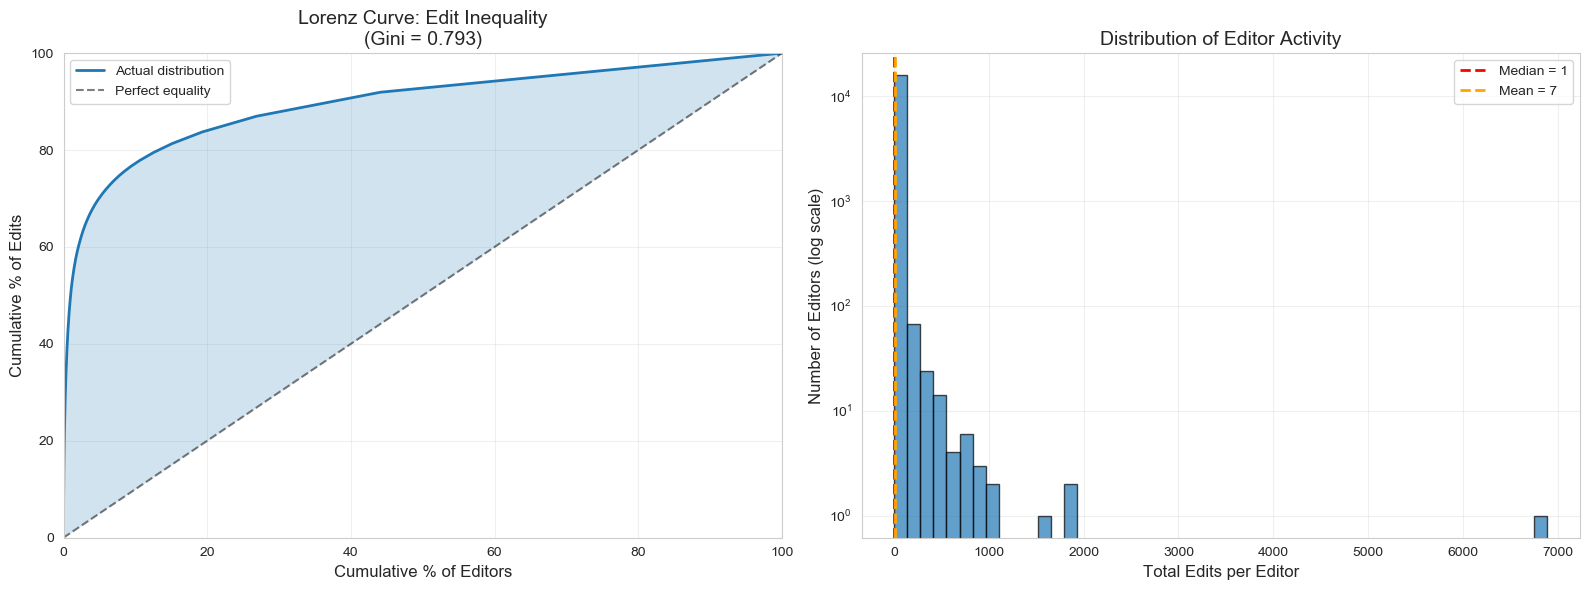


INTERPRETATION
→ HIGH concentration: Small group of power users drive most activity
  This suggests Wikipedia editing on Taiwan politics is dominated by dedicated editors

The top 10% of editors produce 77% of content


In [67]:
if df_editors_agg is not None:
    print("\n" + "="*80)
    print("7a. EDIT CONCENTRATION ANALYSIS")
    print("="*80)
    
    # FIX: Aggregate page-level editor data to get overall editor statistics
    # df_editors has columns: page_title, user, num_edits, ...
    # We need to aggregate by user to get total edits per editor
    
    print("\nAggregating page-level editor data...")
    editor_overall = df_editors.groupby('user').agg({
        'num_edits': 'sum',  # Total edits across all pages
        'page_title': 'nunique',  # Number of unique pages edited
        'first_edit': 'min',  # Earliest edit
        'last_edit': 'max',  # Latest edit
        'total_size_change': 'sum',  # Total size change
        'minor_edits': 'sum'  # Total minor edits
    }).reset_index()
    
    # Rename columns for clarity
    editor_overall.columns = ['editor', 'total_edits', 'pages_edited', 'first_edit', 
                              'last_edit', 'total_size_change', 'total_minor_edits']
    
    # Sort by total edits
    editor_edits = df_editors_agg.sort_values('total_edits', ascending=False)

    
    print(f"✓ Aggregated to {len(editor_edits):,} unique editors")
    
    # Calculate Gini coefficient
    def gini_coefficient(x):
        """Calculate Gini coefficient for inequality measurement"""
        n = len(x)
        x_sorted = np.sort(x)
        cumsum = np.cumsum(x_sorted)
        return (2 * np.sum((np.arange(1, n+1)) * x_sorted)) / (n * cumsum[-1]) - (n + 1) / n
    
    gini = gini_coefficient(editor_edits['total_edits'].values)
    
    # Top percentiles
    total_edits = editor_edits['total_edits'].sum()
    top10_edits = editor_edits.head(int(len(editor_edits) * 0.1))['total_edits'].sum()
    top1_edits = editor_edits.head(int(max(1, len(editor_edits) * 0.01)))['total_edits'].sum()
    
    print(f"\nOVERALL EDIT CONCENTRATION")
    print("-"*80)
    print(f"Total editors: {len(editor_edits):,}")
    print(f"Total edits: {total_edits:,}")
    print(f"Gini coefficient: {gini:.3f} (0=equal, 1=concentrated)")
    print(f"Top 10% of editors account for: {top10_edits/total_edits*100:.1f}% of edits")
    print(f"Top 1% of editors account for: {top1_edits/total_edits*100:.1f}% of edits")
    print(f"Median edits per editor: {editor_edits['total_edits'].median():.0f}")
    print(f"Mean edits per editor: {editor_edits['total_edits'].mean():.1f}")
    
    # Show top editors
    print(f"\nTop 10 Most Active Editors:")
    print("-"*80)
    for i, row in editor_edits.head(10).iterrows():
        print(f"  {row['editor'][:30]:30s}: {row['total_edits']:6.0f} edits on {row['pages_edited']:3.0f} pages")
    
    # Visualize concentration
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Panel 1: Lorenz curve
    ax = axes[0]
    cumsum_editors = np.arange(1, len(editor_edits) + 1) / len(editor_edits) * 100
    cumsum_edits = editor_edits['total_edits'].cumsum() / total_edits * 100
    
    ax.plot(cumsum_editors, cumsum_edits, linewidth=2, label='Actual distribution')
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Perfect equality')
    ax.fill_between(cumsum_editors, cumsum_editors, cumsum_edits, alpha=0.2)
    ax.set_xlabel('Cumulative % of Editors', fontsize=12)
    ax.set_ylabel('Cumulative % of Edits', fontsize=12)
    ax.set_title(f'Lorenz Curve: Edit Inequality\n(Gini = {gini:.3f})', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    
    # Panel 2: Edit distribution histogram (log scale)
    ax = axes[1]
    ax.hist(editor_edits['total_edits'], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(editor_edits['total_edits'].median(), color='red', 
               linestyle='--', linewidth=2, label=f'Median = {editor_edits["total_edits"].median():.0f}')
    ax.axvline(editor_edits['total_edits'].mean(), color='orange', 
               linestyle='--', linewidth=2, label=f'Mean = {editor_edits["total_edits"].mean():.0f}')
    ax.set_xlabel('Total Edits per Editor', fontsize=12)
    ax.set_ylabel('Number of Editors (log scale)', fontsize=12)
    ax.set_title('Distribution of Editor Activity', fontsize=14)
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("INTERPRETATION")
    print("="*80)
    if gini > 0.7:
        print("→ HIGH concentration: Small group of power users drive most activity")
        print("  This suggests Wikipedia editing on Taiwan politics is dominated by dedicated editors")
    elif gini > 0.5:
        print("→ MODERATE concentration: Mix of power users and casual editors")
        print("  Both dedicated and occasional editors contribute significantly")
    else:
        print("→ LOW concentration: Edits distributed broadly across many editors")
        print("  Participation is relatively democratic")
    
    print(f"\nThe top 10% of editors produce {top10_edits/total_edits*100:.0f}% of content")
    if top10_edits/total_edits > 0.8:
        print("  → Highly concentrated: Consider investigating these key editors")
    
    print("="*80)
else:
    print("⚠ Editor data not available. Skipping concentration analysis.")


### 7b. Editor Profiles by Page Type

**Question**: Can we identify "partisan" editors or content specialists based on 
what they edit?

**Methods**:
- Editor specialization: Do they focus on one party/politician or edit broadly?
- Partisan affinity score: % of edits on each party's pages
- Specialist vs generalist classification


In [61]:
if df_revisions is not None and df_page_daily is not None:
    print("\n" + "="*80)
    print("7b. EDITOR PROFILES & CONTENT FOCUS")
    print("="*80)
    
    # Merge revisions with page categories
    page_to_category = df_page_daily[['page_title', 'page_category']].drop_duplicates()
    df_revisions_cat = df_revisions.merge(page_to_category, 
                                          left_on='page_title', 
                                          right_on='page_title', 
                                          how='left')
    
    # Fill missing categories
    df_revisions_cat['page_category'] = df_revisions_cat['page_category'].fillna('unknown')
    
    # Editor-level category distribution
    editor_category = df_revisions_cat.groupby(['editor', 'page_category']).size().reset_index(name='edits')
    
    # Calculate specialization index (Herfindahl-Hirschman Index)
    def calculate_specialization(group):
        """Calculate HHI: 0=perfect diversity, 1=complete specialization"""
        total = group['edits'].sum()
        shares = (group['edits'] / total) ** 2
        return shares.sum()
    
    editor_specialization = editor_category.groupby('editor').apply(calculate_specialization).reset_index(name='hhi')
    
    # Classify editors
    editor_specialization['type'] = pd.cut(editor_specialization['hhi'], 
                                           bins=[0, 0.4, 0.7, 1.0],
                                           labels=['Generalist', 'Mixed', 'Specialist'])
    
    print("\nEDITOR SPECIALIZATION")
    print("-"*80)
    print(editor_specialization['type'].value_counts())
    print(f"\nMean HHI: {editor_specialization['hhi'].mean():.3f}")
    print(f"Median HHI: {editor_specialization['hhi'].median():.3f}")
    
    # Analyze party focus for editors
    # First, need to identify party pages
    party_keywords = {
        'DPP': ['民進黨', '民主進步黨'],
        'KMT': ['國民黨', '中國國民黨'],
        'TPP': ['台灣民眾黨', '民眾黨'],
        'NPP': ['時代力量'],
        'PFP': ['親民黨']
    }
    
    def identify_party_focus(title):
        """Identify which party a page is about"""
        for party, keywords in party_keywords.items():
            if any(kw in title for kw in keywords):
                return party
        return 'Other'
    
    df_revisions_cat['party_focus'] = df_revisions_cat['page_title'].apply(identify_party_focus)
    
    # Editor-party affinity
    editor_party = df_revisions_cat[df_revisions_cat['party_focus'] != 'Other'].groupby(
        ['editor', 'party_focus']
    ).size().reset_index(name='edits')
    
    # Calculate party affinity scores
    editor_party_total = editor_party.groupby('editor')['edits'].sum().reset_index(name='total_party_edits')
    editor_party = editor_party.merge(editor_party_total, on='editor')
    editor_party['affinity_score'] = editor_party['edits'] / editor_party['total_party_edits']
    
    # Identify editors with strong party focus (>70% on one party)
    strong_party_editors = editor_party[editor_party['affinity_score'] > 0.7]
    
    print("\n" + "-"*80)
    print("PARTY-FOCUSED EDITORS (>70% edits on one party's pages)")
    print("-"*80)
    if len(strong_party_editors) > 0:
        for party in strong_party_editors['party_focus'].unique():
            party_eds = strong_party_editors[strong_party_editors['party_focus'] == party]
            print(f"{party}: {len(party_eds)} editors")
    else:
        print("No editors with strong single-party focus detected")
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Panel 1: Specialization distribution
    ax = axes[0, 0]
    ax.hist(editor_specialization['hhi'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(editor_specialization['hhi'].median(), color='red', 
               linestyle='--', linewidth=2, label=f'Median = {editor_specialization["hhi"].median():.2f}')
    ax.set_xlabel('Specialization Index (HHI)')
    ax.set_ylabel('Number of Editors')
    ax.set_title('Editor Specialization Distribution\n(0=generalist, 1=specialist)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Category focus by editor type
    ax = axes[0, 1]
    editor_cat_type = editor_category.merge(editor_specialization[['editor', 'type']], on='editor')
    pivot = editor_cat_type.pivot_table(index='page_category', columns='type', 
                                        values='edits', aggfunc='sum')
    pivot.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Page Category')
    ax.set_ylabel('Total Edits')
    ax.set_title('Content Focus by Editor Type')
    ax.legend(title='Editor Type')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Panel 3: Party affinity distribution
    ax = axes[1, 0]
    party_counts = editor_party.groupby('party_focus')['editor'].nunique().sort_values(ascending=False)
    ax.bar(range(len(party_counts)), party_counts.values)
    ax.set_xticks(range(len(party_counts)))
    ax.set_xticklabels(party_counts.index)
    ax.set_xlabel('Party')
    ax.set_ylabel('Number of Editors')
    ax.set_title('Editors Who Edit Party Pages')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Panel 4: Strong party affinity
    ax = axes[1, 1]
    if len(strong_party_editors) > 0:
        strong_counts = strong_party_editors.groupby('party_focus')['editor'].nunique()
        ax.bar(range(len(strong_counts)), strong_counts.values)
        ax.set_xticks(range(len(strong_counts)))
        ax.set_xticklabels(strong_counts.index)
        ax.set_xlabel('Party')
        ax.set_ylabel('Number of "Dedicated" Editors')
        ax.set_title('Editors with Strong Party Focus (>70% edits)')
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'No editors with >70% focus\non a single party detected', 
                ha='center', va='center', fontsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()



7b. EDITOR PROFILES & CONTENT FOCUS


KeyError: 'editor'

### 7c. Temporal Editing Patterns

**Question**: Do editors appear specifically around elections ("election tourists") 
or contribute year-round?

**Methods**:
- First edit timing relative to elections
- Activity concentration around election dates
- "Burst" vs "steady" editing patterns


In [62]:
if df_revisions is not None:
    print("\n" + "="*80)
    print("7c. TEMPORAL EDITING PATTERNS")
    print("="*80)
    
    # For each editor, calculate their temporal pattern
    editor_temporal = df_revisions.groupby('editor').agg({
        'timestamp': ['min', 'max', 'count'],
        'page_title': 'nunique'
    }).reset_index()
    editor_temporal.columns = ['editor', 'first_edit', 'last_edit', 'total_edits', 'pages_edited']
    editor_temporal['active_days'] = (editor_temporal['last_edit'] - editor_temporal['first_edit']).dt.days + 1
    editor_temporal['edits_per_day'] = editor_temporal['total_edits'] / editor_temporal['active_days']
    
    # Calculate temporal concentration (burst vs steady)
    # Group edits by date for each editor
    editor_daily = df_revisions.groupby(['editor', pd.Grouper(key='timestamp', freq='D')]).size().reset_index(name='daily_edits')
    
    def calculate_temporal_concentration(group):
        """Calculate concentration of edits over time (Gini-like)"""
        if len(group) < 2:
            return 1.0
        return gini_coefficient(group['daily_edits'].values)
    
    editor_burst = editor_daily.groupby('editor').apply(calculate_temporal_concentration).reset_index(name='temporal_gini')
    editor_temporal = editor_temporal.merge(editor_burst, on='editor', how='left')
    
    # Classify editors
    editor_temporal['pattern'] = 'Steady'
    editor_temporal.loc[editor_temporal['temporal_gini'] > 0.7, 'pattern'] = 'Bursty'
    editor_temporal.loc[editor_temporal['total_edits'] < 5, 'pattern'] = 'One-time'
    
    print("\nTEMPORAL EDITING PATTERNS")
    print("-"*80)
    print(editor_temporal['pattern'].value_counts())
    
    # Analyze timing relative to elections
    # Check if editors' first edit is close to an election
    def days_to_nearest_election(date):
        """Calculate days to nearest election"""
        days_to_elections = [(date - e).days for e in events['date']]
        return min(days_to_elections, key=abs)
    
    editor_temporal['days_to_election'] = editor_temporal['first_edit'].apply(days_to_nearest_election)
    
    # Classify: within 60 days of election = "Election-driven"
    editor_temporal['timing'] = 'Year-round'
    editor_temporal.loc[abs(editor_temporal['days_to_election']) <= 60, 'timing'] = 'Election-driven'
    
    print("\n" + "-"*80)
    print("EDITOR TIMING")
    print("-"*80)
    print(editor_temporal['timing'].value_counts())
    print(f"\nMedian days to nearest election: {editor_temporal['days_to_election'].abs().median():.0f}")
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Panel 1: Active days distribution
    ax = axes[0, 0]
    ax.hist(editor_temporal['active_days'], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(editor_temporal['active_days'].median(), color='red', 
               linestyle='--', linewidth=2, label=f'Median = {editor_temporal["active_days"].median():.0f} days')
    ax.set_xlabel('Active Days (first to last edit)')
    ax.set_ylabel('Number of Editors')
    ax.set_title('Editor Activity Duration')
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Temporal concentration
    ax = axes[0, 1]
    pattern_counts = editor_temporal['pattern'].value_counts()
    ax.bar(range(len(pattern_counts)), pattern_counts.values)
    ax.set_xticks(range(len(pattern_counts)))
    ax.set_xticklabels(pattern_counts.index)
    ax.set_xlabel('Editing Pattern')
    ax.set_ylabel('Number of Editors')
    ax.set_title('Burst vs Steady Editing Behavior')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Panel 3: Days to nearest election (first edit)
    ax = axes[1, 0]
    ax.hist(editor_temporal['days_to_election'], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Election day')
    ax.set_xlabel('Days from First Edit to Nearest Election')
    ax.set_ylabel('Number of Editors')
    ax.set_title('When Do Editors First Appear?\n(Negative = before election)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel 4: Timing classification
    ax = axes[1, 1]
    timing_counts = editor_temporal['timing'].value_counts()
    ax.bar(range(len(timing_counts)), timing_counts.values)
    ax.set_xticks(range(len(timing_counts)))
    ax.set_xticklabels(timing_counts.index)
    ax.set_xlabel('Editor Timing Type')
    ax.set_ylabel('Number of Editors')
    ax.set_title('Election-Driven vs Year-Round Editors\n(Election-driven = first edit within 60 days)')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()



7c. TEMPORAL EDITING PATTERNS


KeyError: 'editor'

### 7d. Network Patterns & Potential Coordination

**Question**: Do certain editors edit the same pages at similar times, 
suggesting coordination?

**Methods**:
- Co-editing network: Editors linked if they edit same pages
- Temporal clustering: Editors who edit same pages within short time windows
- Unusual patterns that might indicate organized behavior


In [ ]:
if df_revisions is not None:
    print("\n" + "="*80)
    print("7d. COORDINATION INDICATORS")
    print("="*80)
    
    # Analyze co-editing patterns
    # For each page, find editors who edited it
    page_editors = df_revisions.groupby('page_title')['editor'].apply(list).to_dict()
    
    # Count co-editing (editors who edited same pages)
    from collections import defaultdict
    from itertools import combinations
    
    coediting_matrix = defaultdict(int)
    
    for page, editors in page_editors.items():
        unique_editors = set(editors)
        if len(unique_editors) > 1:
            for editor1, editor2 in combinations(sorted(unique_editors), 2):
                coediting_matrix[(editor1, editor2)] += 1
    
    # Convert to dataframe
    if len(coediting_matrix) > 0:
        coediting_df = pd.DataFrame([
            {'editor1': k[0], 'editor2': k[1], 'shared_pages': v}
            for k, v in coediting_matrix.items()
        ])
        
        print(f"\nCO-EDITING NETWORK")
        print("-"*80)
        print(f"Total editor pairs with shared pages: {len(coediting_df):,}")
        print(f"Max shared pages between two editors: {coediting_df['shared_pages'].max()}")
        print(f"Median shared pages: {coediting_df['shared_pages'].median():.0f}")
        
        # Identify highly connected editor pairs
        high_overlap = coediting_df[coediting_df['shared_pages'] > coediting_df['shared_pages'].quantile(0.95)]
        print(f"\nHighly connected pairs (top 5%): {len(high_overlap)}")
        
        # Temporal clustering: Editors editing same page within 24 hours
        print("\n" + "-"*80)
        print("TEMPORAL CLUSTERING (edits within 24 hours)")
        print("-"*80)
        
        temporal_clusters = []
        for page in df_revisions['page_title'].unique()[:100]:  # Sample to avoid long computation
            page_revs = df_revisions[df_revisions['page_title'] == page].sort_values('timestamp')
            
            if len(page_revs) > 1:
                for i in range(len(page_revs) - 1):
                    time_diff = (page_revs.iloc[i+1]['timestamp'] - page_revs.iloc[i]['timestamp']).total_seconds() / 3600
                    if time_diff < 24 and page_revs.iloc[i]['editor'] != page_revs.iloc[i+1]['editor']:
                        temporal_clusters.append({
                            'page': page,
                            'editor1': page_revs.iloc[i]['editor'],
                            'editor2': page_revs.iloc[i+1]['editor'],
                            'hours_apart': time_diff
                        })
        
        if len(temporal_clusters) > 0:
            temporal_df = pd.DataFrame(temporal_clusters)
            print(f"Found {len(temporal_df)} editor pairs editing same page within 24h (sample of 100 pages)")
            print(f"Median time between edits: {temporal_df['hours_apart'].median():.1f} hours")
        else:
            print("No temporal clustering detected in sample")
        
        # Visualize co-editing network (top connections only)
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Panel 1: Distribution of shared pages
        ax = axes[0]
        ax.hist(coediting_df['shared_pages'], bins=30, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Number of Shared Pages Between Editor Pairs')
        ax.set_ylabel('Number of Editor Pairs')
        ax.set_title('Co-Editing Connections')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        
        # Panel 2: Temporal clustering distribution
        ax = axes[1]
        if len(temporal_clusters) > 0:
            ax.hist(temporal_df['hours_apart'], bins=30, edgecolor='black', alpha=0.7)
            ax.set_xlabel('Hours Between Sequential Edits')
            ax.set_ylabel('Number of Editor Pairs')
            ax.set_title('Temporal Clustering: Time Between Edits\n(Same page, different editors)')
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'Insufficient data for\ntemporal clustering analysis', 
                    ha='center', va='center', fontsize=12)
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*80)
        print("INTERPRETATION")
        print("="*80)
        print("High co-editing overlap: Could indicate")
        print("  • Editors with similar interests")
        print("  • Potential coordination (if combined with temporal clustering)")
        print("  • Normal collaborative editing behavior")
        print("\nTemporal clustering: Edits within hours could suggest")
        print("  • Active monitoring of changes")
        print("  • Coordinated campaigns")
        print("  • Normal response to news events")
        
    else:
        print("No co-editing patterns detected")


### 7e. Summary: Editor-Level Insights

**Key Findings to Report:**
1. Edit concentration (Gini coefficient): How unequal is participation?
2. Editor types: % Specialists vs generalists
3. Party focus: Any evidence of partisan editing patterns?
4. Temporal patterns: % Election-driven vs year-round contributors
5. Coordination indicators: Unusual clustering or co-editing patterns?

**Implications:**
- If edits are highly concentrated: Small group drives narrative
- If strong party specialization: Evidence of partisan activity
- If high election-driven activity: Elections mobilize new editors
- If temporal clustering: Possible coordinated campaigns


In [ ]:
print("\n" + "="*80)
print("SECTION 7 SUMMARY: EDITOR-LEVEL ANALYSIS COMPLETE")
print("="*80)
print("\nThis section analyzed WHO edits and HOW they edit:")
print("  ✓ 7a. Edit concentration & participation breadth")
print("  ✓ 7b. Editor profiles & content focus")
print("  ✓ 7c. Temporal patterns (election-driven vs year-round)")
print("  ✓ 7d. Coordination indicators")
print("\nNext steps: Use these insights to contextualize aggregate patterns from Sections 1-6")
print("="*80)


## 8. Summary and Next Steps

**Pre-election analysis so far:**
1. Event study plots show editing activity patterns around 5 elections (3 national, 2 local)
2. Statistical tests compare 30-day and 90-day pre-election windows to baseline with 90% CI
3. Page category breakdown shows heterogeneous effects across legislators, parties, and general pages
4. 5. Robustness checks and alternative specifications

**Next Steps:**
1. Validate data quality, check for outliers and data coverage issues
2. Implement regression analysis with controls (day-of-week fixed effects, page fixed effects)
3. Test hypotheses about grassroots mobilization effects
4. Examine editor-level patterns (new vs. returning editors)
